# Training the transformer - gold

Runs the actual training loop: many "rooms" (windows), each nudging the same shared set of dials a little, over many epochs, while watching validation loss to catch overfitting. Rebuilds the data pipeline (notebook 09) and model (notebook 10) since each notebook runs independently.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
WINDOW_SIZE = 30

## Rebuild the data pipeline

**Updated split**: instead of a flat 70/15/15 by window count, the test set is now pinned to GARCH's exact test period (2023-04-12 onward, notebook 07) so the two models are honestly comparable with zero overlap. Train/validation are carved from everything *before* that date (85/15), so validation never touches any date GARCH or the final comparison will be scored on.

In [2]:
GARCH_TEST_START = "2023-04-12"

gold = pd.read_csv("../data/gold_futures.csv", skiprows=[1, 2], index_col=0, parse_dates=True)
returns = gold["Close"].pct_change().dropna() * 100


def create_windows(returns, window_size):
    values = returns.values
    X, y, dates = [], [], []
    for start in range(len(values) - window_size):
        end = start + window_size
        X.append(values[start:end])
        y.append(abs(values[end]))
        dates.append(returns.index[end])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32), pd.DatetimeIndex(dates)


X, y, dates = create_windows(returns, WINDOW_SIZE)

test_mask = dates >= GARCH_TEST_START
X_pretest, y_pretest = X[~test_mask], y[~test_mask]
X_test, y_test = X[test_mask], y[test_mask]

train_end = int(len(X_pretest) * 0.85)
X_train, y_train = X_pretest[:train_end], y_pretest[:train_end]
X_val, y_val = X_pretest[train_end:], y_pretest[train_end:]

train_mean = X_train.mean()
train_std = X_train.std()
X_train_norm = (X_train - train_mean) / train_std
X_val_norm = (X_val - train_mean) / train_std
X_test_norm = (X_test - train_mean) / train_std


def to_dataset(X, y):
    X_t = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
    y_t = torch.tensor(y, dtype=torch.float32)
    return TensorDataset(X_t, y_t)


train_dataset = to_dataset(X_train_norm, y_train)
val_dataset = to_dataset(X_val_norm, y_val)
test_dataset = to_dataset(X_test_norm, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Train: {len(train_dataset)}  Val: {len(val_dataset)}  Test: {len(test_dataset)}")
print(f"Test date range: {dates[test_mask][0].date()} to {dates[test_mask][-1].date()}")

Train: 2810  Val: 496  Test: 834
Test date range: 2023-04-12 to 2026-08-05


## Rebuild the model (same as notebook 10)

In [3]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[: x.size(1)]


class VolatilityTransformer(nn.Module):
    def __init__(self, d_model=32, num_heads=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.input_projection = nn.Linear(1, d_model)
        self.pos_encoding = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=64,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.output_head = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.input_projection(x)
        x = self.pos_encoding(x)
        x = self.encoder(x)
        last_day = x[:, -1, :]
        out = self.output_head(last_day)
        return nn.functional.softplus(out).squeeze(-1)


model = VolatilityTransformer()
sum(p.numel() for p in model.parameters())

17185

## Loss function and optimizer

`MSELoss` (mean squared error) measures how wrong each guess was - same idea as the RMSE we used to score GARCH, just squared rather than square-rooted, since squared error is what's actually easier to compute gradients from.

`Adam` is the optimizer - the "nudge every dial slightly downhill" mechanism from the room analogy's training explanation. `lr=1e-3` (the learning rate) controls how big each nudge is - too large and training becomes unstable, too small and it takes forever to learn anything.

**Update after diagnosing notebook 12**: the first attempt (`lr=1e-3`) collapsed to predicting close to the average every time (predictions had only 9% of the real data's spread) - a sign the step size was too large and the optimizer overshot past a more responsive solution. Lowering to `lr=1e-4` here, with more epochs to compensate for the smaller steps.

In [4]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

## The training loop

For each epoch: run every training batch through the model (forward pass), compute the loss, backpropagate, nudge the dials (optimizer step) - that's `model.train()`. Then, separately, check performance on the validation set with `model.eval()` and no dial-nudging (`torch.no_grad()`) - this is the honest "is it actually learning or just memorizing" check.

We keep a copy of the model's dials from whichever epoch had the *best* validation loss, not just the final epoch - since more training isn't always better if validation loss starts rising (overfitting).

In [5]:
NUM_EPOCHS = 150
train_losses, val_losses = [], []
best_val_loss = float("inf")
best_state = None

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = loss_fn(predictions, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(batch_y)
    train_loss = running_loss / len(train_dataset)

    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            predictions = model(batch_X)
            loss = loss_fn(predictions, batch_y)
            running_val_loss += loss.item() * len(batch_y)
    val_loss = running_val_loss / len(val_dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1:3d}/{NUM_EPOCHS}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

model.load_state_dict(best_state)
print(f"\nBest validation loss: {best_val_loss:.4f} (MSE, percent-squared units)")

Epoch  10/150  train_loss=0.5113  val_loss=0.4076


Epoch  20/150  train_loss=0.5103  val_loss=0.4081


Epoch  30/150  train_loss=0.5043  val_loss=0.4092


Epoch  40/150  train_loss=0.5027  val_loss=0.4097


Epoch  50/150  train_loss=0.4990  val_loss=0.4092


...

Epoch 110/150  train_loss=0.4847  val_loss=0.4157


Epoch 120/150  train_loss=0.4817  val_loss=0.4181


Epoch 130/150  train_loss=0.4790  val_loss=0.4191


Epoch 140/150  train_loss=0.4769  val_loss=0.4215


Epoch 150/150  train_loss=0.4773  val_loss=0.4197

Best validation loss: 0.4045 (MSE, percent-squared units)


## Plot train vs. validation loss

If both curves fall together, the model is learning genuinely. If train loss keeps falling while validation loss flattens or rises, that's overfitting - memorizing the training rooms rather than learning something that generalizes.

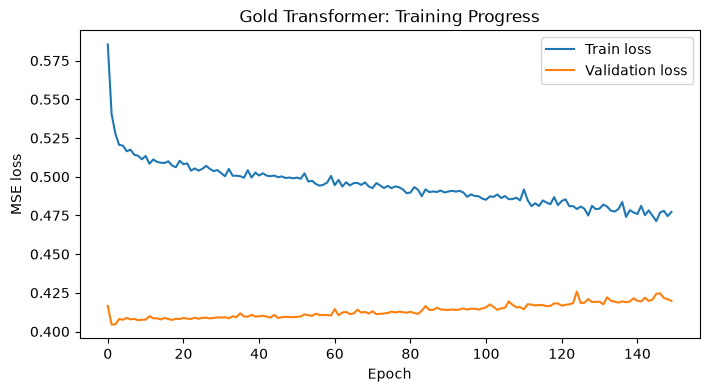

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label="Train loss")
ax.plot(val_losses, label="Validation loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.set_title("Gold Transformer: Training Progress")
ax.legend()
plt.show()

## Save the trained model

Saves only the *dials* (`state_dict`), not the code - same idea as GARCH's fitted `omega/alpha/beta` being separate from the formula itself. The next notebook (evaluation) loads this file rather than retraining from scratch. `models/` is gitignored, same reasoning as `data/` - it's regeneratable by rerunning this notebook.

In [7]:
torch.save(
    {"state_dict": model.state_dict(), "train_mean": train_mean, "train_std": train_std},
    "../models/gold_transformer.pt",
)
print("Saved to ../models/gold_transformer.pt")

Saved to ../models/gold_transformer.pt
